In [ ]:
# Calculadora química 
# Modelo ML: Gaussian Process Regression
# Kernel: Tanimoto
# Descriptor: Fingerprint
# MaxMinPicker.LazyPick()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns 
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from rdkit.DataStructs import TanimotoSimilarity
from rdkit.DataStructs.cDataStructs import ExplicitBitVect
from rdkit.SimDivFilters.rdSimDivPickers import MaxMinPicker
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.model_selection import train_test_split
from tanimoto import FastTanimotoKernel

In [13]:
%matplotlib inline
%config InlineBackend.figure_formats = ['svg']

In [14]:
class ChemCalculator(FastTanimotoKernel):
    def __init__(self, data_set):
        super().__init__()
        self.data_set = data_set
        self.fingerprint = []
        self.read_set = pd.read_csv(self.data_set)

    def show_data(self):
        # Show database
        print(self.read_set)

    def select_data(self, smiles, property, number_of_data):
        # Select the size and the features
        self.read_set = self.read_set[0:number_of_data] # poolsize
        self.data_smiles = self.read_set[smiles]
        self.data_property = self.read_set[property]

        self.data_smiles = self.data_smiles.tolist()
        self.data_property = self.data_property.tolist()
        return self.data_smiles, self.data_property
    
    def convert_smiles_to_fingerprint(self, data_smiles, radius=2, nBits=2048):
        # Convert SMILES in to vectors
        self.molecul = Chem.MolFromSmiles(data_smiles)
        self.fp = AllChem.GetMorganFingerprintAsBitVect(self.molecul, radius=radius, nBits=nBits)
        return self.fp
    
    def matrix_fingerprints(self):
        # Make a matrix with fingerprints vectors
        self.fingerprint = []
        if self.data_smiles:
            self.fingerprint = [self.convert_smiles_to_fingerprint(smile) for smile in self.data_smiles]
        else:
            print("No data SMILES selected. Please use select_data method first.")
    
    def distance_tanimoto(self, i, j, fps = None):
        if fps == None:
            fps = self.fingerprint
        return 1.0 - DataStructs.TanimotoSimilarity(fps[i],fps[j])
    
    def most_diverse_data(self):
        # Make diverse the data 
        if self.fingerprint:
            self.n_total = len(self.fingerprint)
            self.subset_size = 9000
            self.ids = MaxMinPicker().LazyPick(self.distance_tanimoto,self.n_total,self.subset_size)
            self.ids = list(self.ids)

            self.fingerprint = [self.fingerprint[id] for id in self.ids]
            self.property = [self.data_property[id] for id in self.ids]
            return self.fingerprint, self.property
        else:
            print("No fingerprints. Please verify and use matrix_fingerprints().")

    def prepare_data(self):
        # Select the percentage of train data and define the X_train, y_train, X_test and y_test
        if self.fingerprint and self.property:
            self.y = self.property
            self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(self.fingerprint, self.y, test_size=0.2, random_state=42)

            return self.X_train, self.X_test, self.y_train, self.y_test
        
    def get_fingerprints(self):
        if not self.fingerprint:
            print("Fingerprint matrix is empty. Please use matrix_fingerprints method first.")
        return self.fingerprint
    
    def gp_train(self):
        # Train the model
        if not self.X_train or not self.y_train:
            print("Fingerprint matrix or property data is missing. Please ensure both are available.")
            return None
        self.kernel = FastTanimotoKernel()
        self.gp = GaussianProcessRegressor(kernel=self.kernel,alpha=1e-6, normalize_y=True)
        self.gp.fit(self.X_train, self.y_train)
        return self.gp
    
    def gp_input_predict(self, test_smiles):
        self.test_fp = [self.convert_smiles_to_fingerprint(smile) for smile in test_smiles]
        self.X_new = np.array(self.test_fp, dtype=object)
        self.y_pred, self.y_std = self.gp.predict(self.X_new, return_std=True)
        print("Predicted values:", self.y_pred)

    def gp_predict(self):
        self.y_pred, self.y_std = self.gp.predict(self.X_test, return_std=True)
        print("Predicted values:", self.y_pred)
        print("Uncertainity:",self.y_std)

    def get_realvalue(self):
        return self.y_test

    def get_predictions(self):
        return self.y_pred
    
    def get_uncertainty(self):
        return self.y_std
        
    def plot_regression(self, y_true, y_pred, y_std=None, ideal_line=True, cmap="viridis", s=30, alpha=0.9, ax=None, xlabel="Actual", 
                        ylabel="Predicted", title=None, equal_aspect=True, show_stats=True, stats_fmt="{name} = {value:.3f}", add_colorbar=True,):
        
        y_true = np.asarray(y_true).ravel()
        y_pred = np.asarray(y_pred).ravel()

        if y_true.shape != y_pred.shape:
            raise ValueError("y_true and y_pred must have the same shape after ravel().")

        if y_std is not None:
            y_std = np.asarray(y_std).ravel()
            if y_std.shape != y_true.shape:
                raise ValueError("y_std must have the same shape as y_true/y_pred.")

        # Drop non-finite rows
        if y_std is None:
            m = np.isfinite(y_true) & np.isfinite(y_pred)
        else:
            m = np.isfinite(y_true) & np.isfinite(y_pred) & np.isfinite(y_std)

        y_true = y_true[m]
        y_pred = y_pred[m]
        if y_std is not None:
            y_std = y_std[m]

        # Create axis
        if ax is None:
            fig, ax = plt.subplots(figsize=(6.6, 5.6), constrained_layout=True)
        else:
            fig = ax.figure

        # Scatter
        if y_std is None:
            sc = ax.scatter(y_true, y_pred, s=s, alpha=alpha, edgecolor="none", zorder=3)
        else:
            sc = ax.scatter(
                y_true, y_pred,
                c=y_std,
                cmap=cmap,
                s=s,
                alpha=alpha,
                edgecolor="none",
                zorder=3,
            )

        # Reference line y=x over data range
        if ideal_line:
            lo = np.nanmin([y_true.min(), y_pred.min()])
            hi = np.nanmax([y_true.max(), y_pred.max()])
            pad = 0.03 * (hi - lo if hi > lo else 1.0)
            lo -= pad
            hi += pad
            ax.plot([lo, hi], [lo, hi], "--", linewidth=1.8, zorder=1)

        # Stats box
        if show_stats:
            resid = y_true - y_pred
            rmse = np.sqrt(np.mean(resid**2))
            mae = np.mean(np.abs(resid))
            ss_res = np.sum((y_true - y_pred) ** 2)
            ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
            r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

            stats_text = "\n".join([
                stats_fmt.format(name="R²", value=r2),
                stats_fmt.format(name="MAE", value=mae),
                stats_fmt.format(name="RMSE", value=rmse),
            ])
                    # Pick least-crowded corner using medians in parity space
        xmid = np.median(y_true)
        ymid = np.median(y_pred)
        corners = {
            "upper left":  ((y_true < xmid) & (y_pred > ymid)).sum(),
            "upper right": ((y_true > xmid) & (y_pred > ymid)).sum(),
            "lower left":  ((y_true < xmid) & (y_pred < ymid)).sum(),
            "lower right": ((y_true > xmid) & (y_pred < ymid)).sum(),
        }
        loc = min(corners, key=corners.get)

        ax.text(
            0.02 if "left" in loc else 0.98,
            0.98 if "upper" in loc else 0.02,
            stats_text,
            transform=ax.transAxes,
            ha="left" if "left" in loc else "right",
            va="top" if "upper" in loc else "bottom",
            fontsize=10,
            bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="0.5", alpha=0.9),
            zorder=10,
        )

        # Colorbar
        if add_colorbar and (y_std is not None):
            cbar = fig.colorbar(sc, ax=ax, pad=0.02)
            cbar.set_label("Predictive uncertainty (std)")

        # Style
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        if title is not None:
            ax.set_title(title)

        ax.grid(True, alpha=0.25)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        if equal_aspect:
            ax.set_aspect("equal", adjustable="box")

        return ax

In [15]:
propCal = ChemCalculator("qm9.csv")

In [16]:
propCal.select_data(smiles="smiles", property="gap", number_of_data=25000)
propCal.matrix_fingerprints()
propCal.most_diverse_data()
propCal.prepare_data()
propCal.gp_train()

GaussianProcessRegressor(alpha=1e-06, kernel=FastTanimotoKernel(),
                         normalize_y=True)

In [17]:
propCal.gp_predict()

Predicted values: [0.25146385 0.27234728 0.23445712 ... 0.21416674 0.32442632 0.25068193]
Uncertainity: [0.0302112  0.03249473 0.03255655 ... 0.03169026 0.03135956 0.03303221]


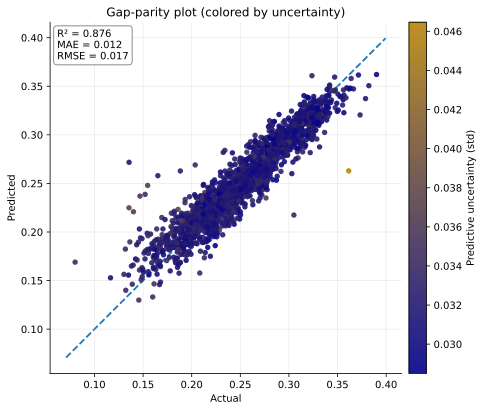

In [18]:
## Puma cmap generator:
cmap_name = 'DarkBlueToDarkGold'
colors = ['#00008B', '#B8860B']

puma_cmap = mcolors.LinearSegmentedColormap.from_list(
    cmap_name, colors, N=256)

propCal.plot_regression(
    propCal.get_realvalue(),
    propCal.get_predictions(),
    propCal.get_uncertainty(),
    cmap=puma_cmap,
    title="Gap-parity plot (colored by uncertainty)"
)
plt.savefig("graphs/predictionII.svg",format='svg')
plt.show()

In [19]:
df = pd.DataFrame({
    "gap_real": propCal.get_realvalue(),
    "gap_pred": propCal.get_predictions(),
    "e_std": propCal.get_uncertainty()
})
df.to_excel("most_diverseDatIII.xlsx", index=False)